A company wants to compare average delivery times across three different delivery zones to see if there’s a statistically significant difference.

We will use One-Way ANOVA because:

We compare means across more than two groups.

We want to know if at least one group’s mean differs.

In [1]:
import numpy as np
import pandas as pd

np.random.seed(42)  # reproducibility

n_per_group = 20  # sample size per group

# Generate sample delivery times for 3 zones
zone_A = np.random.normal(loc=30, scale=2, size=n_per_group)  # mean 30 mins
zone_B = np.random.normal(loc=32, scale=2, size=n_per_group)  # mean 32 mins
zone_C = np.random.normal(loc=31, scale=2, size=n_per_group)  # mean 31 mins

# Combine into a DataFrame
df_anova = pd.DataFrame({
    "Zone A": zone_A,
    "Zone B": zone_B,
    "Zone C": zone_C
})

print(df_anova.head())


      Zone A     Zone B     Zone C
0  30.993428  34.931298  32.476933
1  29.723471  31.548447  31.342737
2  31.295377  32.135056  30.768703
3  33.046060  29.150504  30.397793
4  29.531693  30.911235  28.042956


In [2]:

from scipy.stats import f_oneway

# Perform one-way ANOVA
f_stat, p_value = f_oneway(df_anova["Zone A"], df_anova["Zone B"], df_anova["Zone C"])

print("\n--- ANOVA Test Results ---")
print("F-statistic:", round(f_stat, 3))
print("p-value:", round(p_value, 4))



--- ANOVA Test Results ---
F-statistic: 5.145
p-value: 0.0088


In [3]:
from scipy.stats import f

alpha = 0.05
df_between = len(df_anova.columns) - 1
df_within = df_anova.size - len(df_anova.columns)

f_crit = f.ppf(1 - alpha, df_between, df_within)

print(f"Critical F-value (α={alpha}):", round(f_crit, 3))

if f_stat > f_crit:
    print("Decision: Reject H0 — significant difference.")
else:
    print("Decision: Fail to reject H0 — no significant difference.")


Critical F-value (α=0.05): 3.159
Decision: Reject H0 — significant difference.


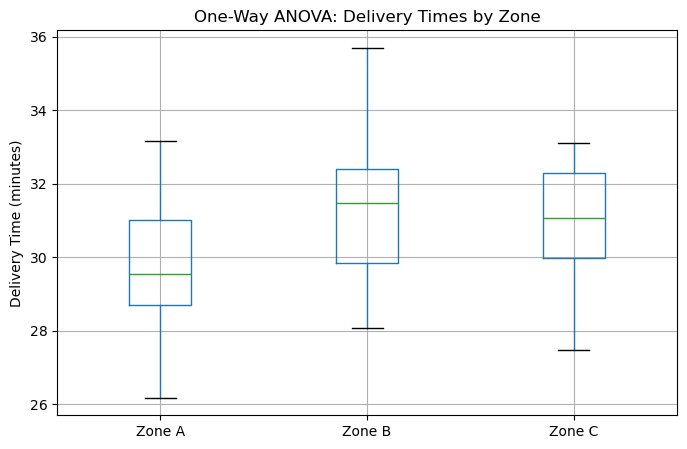

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
df_anova.boxplot()
plt.title("One-Way ANOVA: Delivery Times by Zone")
plt.ylabel("Delivery Time (minutes)")
plt.show()
